# Błędy numeryczne

Zagadnienia:
* Reprezentacja liczb w komputerze:
    * Zapis stałoprzecinkowy,
    * Zapis zmiennoprzecinkowy (standard IEEE 754),
* Błędy numeryczne:
    * Błąd względny i bezwzględny.
    * Błąd zaokrąglenia (ang. *round-off error*).
    * Błąd obcięcia (ang. *truncation error*).
    * Błędy związane z przyjętym sposobem rozwiązywania.

## Błąd względny i bezwzględny

***Zadanie 1.***  
Liczbę $\textrm{e}$ możemy zdefiniować jako $\sum\limits_{n=0}^{\infty} \frac{1}{n!}$. Oblicz błąd względny i bezwzględny aproksymacji liczby $\textrm{e}$ poprzez $\textrm{e}^{*}$ w przypadku gdy:  
* $\textrm{e}_1^{*}=\sum\limits_{n=0}^{5} \frac{1}{n!}$    

* $\textrm{e}_2^{*}=\sum\limits_{n=0}^{10} \frac{1}{n!}$  

* $\textrm{e}_3^{*}=\sum\limits_{n=0}^{20} \frac{1}{n!}$  

In [1]:
import math

e_exact = math.e

for N in [5, 10, 20]:
    e_approx = sum(1 / math.factorial(n) for n in range(N + 1))
    err_abs = abs(e_exact - e_approx)
    err_rel = err_abs / abs(e_exact)
    print(f'N={N:2d}: e* = {e_approx:.15f}, błąd bezwzgl. = {err_abs:.2e}, błąd względny = {err_rel:.2e}')

N= 5: e* = 2.716666666666667, błąd bezwzgl. = 1.62e-03, błąd względny = 5.94e-04
N=10: e* = 2.718281801146385, błąd bezwzgl. = 2.73e-08, błąd względny = 1.00e-08
N=20: e* = 2.718281828459045, błąd bezwzgl. = 0.00e+00, błąd względny = 0.00e+00


## Zapis zmiennoprzecinkowy

**Uwaga**: Używane tu pojęcie **cecha** ma inne znaczenie, niż poznane być może w szkole – skrótowo: „część całkowita”. Dlatego poniżej dodawane jest inne określenie – „wykładnik”.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import sys

In [3]:
print(np.finfo(float))
eps = np.finfo(float).eps

Machine parameters for float64
---------------------------------------------------------------
precision = 15   resolution = 1e-15
machep = -52   eps =        2.220446049250313e-16
negep =  -53   epsneg =     1.1102230246251565e-16
minexp = -1022   tiny =       2.2250738585072014e-308
maxexp = 1024   max =        1.7976931348623157e+308
nexp =   11   min =        -max
smallest_normal = 2.2250738585072014e-308   smallest_subnormal = 5e-324
---------------------------------------------------------------



***Zadanie 2.***


a) Wstaw dowolną wartość do liczby x, np. 0.1. Które liczby mają tę samą mantysę, a które tę samą cechę (wykładnik)? Sprawdź wypisując ich wartości w formacie hex.


**Uwaga:** Do odczytania liczby w formacie szesnastkowym możesz wykorzystać funkcję:

In [4]:
1.25.hex()

'0x1.4000000000000p+0'

In [5]:
5000.0.hex()

'0x1.3880000000000p+12'

lub

In [6]:
import struct
def double_to_hex(f):
    print(hex(struct.unpack('<Q', struct.pack('<d', f))[0]))

In [7]:
double_to_hex(1.25)

0x3ff4000000000000


Zamianę w drugą stronę można przeprowadzić za pomocą funkcji *int*

In [8]:
int('3ff', 16)

1023

In [9]:
x = 0.1

print(f'x     = {x} -> hex: {x.hex()}')
print(f'2*x   = {2*x} -> hex: {(2*x).hex()}')
print(f'4*x   = {4*x} -> hex: {(4*x).hex()}')
print(f'0.5*x = {0.5*x} -> hex: {(0.5*x).hex()}')
print()
print('Ta sama mantysa (różna cecha): x, 2*x, 4*x, 0.5*x')
print('Ta sama cecha (różna mantysa): np. 0.1 i 0.2')
print(f'0.2   = {0.2} -> hex: {0.2.hex()}')

x     = 0.1 -> hex: 0x1.999999999999ap-4
2*x   = 0.2 -> hex: 0x1.999999999999ap-3
4*x   = 0.4 -> hex: 0x1.999999999999ap-2
0.5*x = 0.05 -> hex: 0x1.999999999999ap-5

Ta sama mantysa (różna cecha): x, 2*x, 4*x, 0.5*x
Ta sama cecha (różna mantysa): np. 0.1 i 0.2
0.2   = 0.2 -> hex: 0x1.999999999999ap-3




b) Porównaj zapis liczb 0.1, 0.2 i 0.3 w formacie zmiennoprzecinkowym.

* Czy można przewidzieć, czy suma 0.1 + 0.2 będzie reprezentowana dokładnie tak samo jak liczba 0.3?
* Jaki będzie wynik porównania tej sumy z liczbą 0.3 i konsekwencje użycia warunku równościowego / nierównościowego w pętli?



In [10]:
print(f'0.1       = {0.1.hex()}')
print(f'0.2       = {0.2.hex()}')
print(f'0.3       = {0.3.hex()}')
print(f'0.1 + 0.2 = {(0.1+0.2).hex()}')
print()
print(f'0.1 + 0.2 == 0.3 ? {0.1 + 0.2 == 0.3}')
print(f'Różnica: {(0.1 + 0.2) - 0.3:.2e}')
print()
print('Suma 0.1+0.2 nie jest dokładnie równa 0.3 w arytmetyce zmiennoprzecinkowej.')
print('Użycie warunku == w pętli z takimi liczbami może spowodować pominięcie warunku stopu.')

0.1       = 0x1.999999999999ap-4
0.2       = 0x1.999999999999ap-3
0.3       = 0x1.3333333333333p-2
0.1 + 0.2 = 0x1.3333333333334p-2

0.1 + 0.2 == 0.3 ? False
Różnica: 5.55e-17

Suma 0.1+0.2 nie jest dokładnie równa 0.3 w arytmetyce zmiennoprzecinkowej.
Użycie warunku == w pętli z takimi liczbami może spowodować pominięcie warunku stopu.


c) Przyjmijmy, że „skrótowe” określenie *liczba dokładnie reprezentowana* oznacza liczbę, która jest reprezentowana w formacie zmiennoprzecinkowym dokładnie, tzn. bez konieczności zaokrąglania.
* Ile jest liczb dokładnie reprezentowanych w przedziale $[1, 2)$?
* Zaobserwuj (z pomocą formatu hex) jakie wartości mają bity w polu mantysy w przypadku liczby 1.0.
* Jaką liczbę trzeba dodać do 1.0, aby tylko na najmłodszej pozycji pola mantysy pojawiło się 1?
* Czy wyżej otrzymana suma jest najmniejszą liczbą dokładnie reprezentowana, spośród liczb większych od 1?
* Jak przypuszczasz, jakie wartości będą miały poszczególne bity mantysy w przypadku największej liczby dokładnie reprezentowanej, której cecha (wykładnik) jest równy 0? Sprawdź, czy tak jest rzeczywiście – wpisując wartość tej liczby (jaka to jest wartość?).


In [11]:
# Mantysa w double ma 52 bity -> 2^52 liczb w przedziale [1, 2)
print(f'Liczb dokładnie reprezentowanych w [1,2): 2^52 = {2**52}')
print()

# 1.0 w hex
print(f'1.0 hex: {(1.0).hex()}')
print('Mantysa 1.0 ma same zera (bo 1.0 = 1.0 * 2^0)')
print()

# Najmniejsza liczba do dodania do 1.0 żeby zmienić LSB mantysy = eps
print(f'eps = {eps}')
print(f'1.0 + eps = {(1.0 + eps).hex()}')
print(f'Tak, 1.0 + eps jest najmniejszą liczbą dokładnie reprezentowaną > 1.')
print()

# Największa liczba z cechą 0 -> tuż przed 2.0
max_exp0 = 2.0 - eps
print(f'Największa liczba z cechą 0: {max_exp0}')
print(f'hex: {max_exp0.hex()}')
print('Wszystkie bity mantysy ustawione na 1.')

Liczb dokładnie reprezentowanych w [1,2): 2^52 = 4503599627370496

1.0 hex: 0x1.0000000000000p+0
Mantysa 1.0 ma same zera (bo 1.0 = 1.0 * 2^0)

eps = 2.220446049250313e-16
1.0 + eps = 0x1.0000000000001p+0
Tak, 1.0 + eps jest najmniejszą liczbą dokładnie reprezentowaną > 1.

Największa liczba z cechą 0: 1.9999999999999998
hex: 0x1.fffffffffffffp+0
Wszystkie bity mantysy ustawione na 1.


d) Oblicz długości przedziałów, do których należą wszystkie liczby mające cechę (wykładnik) równy: 0, 1, 2, 5, -1, -3.

* Czy w każdym z tych przedziałów jest tyle samo liczb dokładnie reprezentowanych? Jeżeli nie, to ile w każdym z nich?
* Jaka jest odległość między dwoma sąsiednimi liczbami dokładnie reprezentowanymi (odległość, czyli różnica ich wartości) w każdym z tych przedziałów?
* Jaki jest maksymalny błąd bezwzględny zaokrąglenia w każdym z tych przedziałów?
* Jaki jest maksymalny błąd względny zaokrąglenia w każdym z tych przedziałów?





In [12]:
print(f'{"Cecha":>6} | {"Przedział":>24} | {"Długość":>12} | {"Odległość sąsiadów":>20} | {"Max bł. bezwzgl.":>18} | {"Max bł. względny":>18}')
print('-' * 120)

for e in [0, 1, 2, 5, -1, -3]:
    lo = 2.0 ** e
    hi = 2.0 ** (e + 1)
    length = hi - lo
    spacing = eps * lo       # odległość między sąsiednimi liczbami
    max_abs_err = spacing / 2
    max_rel_err = max_abs_err / lo
    print(f'{e:>6} | [{lo:>10.6f}, {hi:>10.6f}) | {length:>12.6e} | {spacing:>20.6e} | {max_abs_err:>18.6e} | {max_rel_err:>18.6e}')

print()
print(f'W każdym przedziale jest tyle samo liczb: 2^52 = {2**52}')
print(f'Max błąd względny jest stały i równy eps/2 = {eps/2:.2e}')

 Cecha |                Przedział |      Długość |   Odległość sąsiadów |   Max bł. bezwzgl. |   Max bł. względny
------------------------------------------------------------------------------------------------------------------------
     0 | [  1.000000,   2.000000) | 1.000000e+00 |         2.220446e-16 |       1.110223e-16 |       1.110223e-16
     1 | [  2.000000,   4.000000) | 2.000000e+00 |         4.440892e-16 |       2.220446e-16 |       1.110223e-16
     2 | [  4.000000,   8.000000) | 4.000000e+00 |         8.881784e-16 |       4.440892e-16 |       1.110223e-16
     5 | [ 32.000000,  64.000000) | 3.200000e+01 |         7.105427e-15 |       3.552714e-15 |       1.110223e-16
    -1 | [  0.500000,   1.000000) | 5.000000e-01 |         1.110223e-16 |       5.551115e-17 |       1.110223e-16
    -3 | [  0.125000,   0.250000) | 1.250000e-01 |         2.775558e-17 |       1.387779e-17 |       1.110223e-16

W każdym przedziale jest tyle samo liczb: 2^52 = 4503599627370496
Max błąd wzglę

***Zadanie 3.***

Spójrz na poniższe zjawiska, zastanów się nad ich przyczynami.

***Problem skali***

Jaki wynika da poniższy kod:

In [13]:
a = 1.0
b = 0.0000000000000000000000001
c = a + b
print(f'{c:.17f}')

1.00000000000000000


***Problem reprezentacji w zapisie binarnym*** 

In [14]:
if 0.1+0.2==0.3:
    print("True")
else:
    print("False")

False


In [15]:
suma = 0
for i in range(0,100):
    suma += 0.1
print(f'{suma:.15f}')

9.999999999999980


**Zadanie 4.**

Niech:
* $a=0.3$
* $b=10^{-13}$
* $c=a-b$
* $d=a-c$

Czy $b$ i $d$ są sobie równe w sensie analitycznym? Co z przypadkiem numerycznym? Zdefiniuj odpowiednie zmienne i porównaj wyniki. Porównaj szesnastkowe i dziesietne reprezentacje zmiennych `b` i `d`. Ile cyfr w reprezentacji `d` możemy uznać za wiarygodne?

In [16]:
a = 0.3
b = 1e-13
c = a - b
d = a - c

print(f'b = {b}')
print(f'd = {d}')
print(f'b == d ? {b == d}')
print()
print(f'b hex: {b.hex()}')
print(f'd hex: {d.hex()}')
print(f'b = {b:.20e}')
print(f'd = {d:.20e}')
print(f'Różnica b - d = {b - d:.2e}')
print()
print('Analitycznie b == d, ale numerycznie nie.')
print('d ma tylko ok. 3-4 wiarygodne cyfry z powodu utraty cyfr znaczących (catastrophic cancellation).')

b = 1e-13
d = 9.997558336749535e-14
b == d ? False

b hex: 0x1.c25c268497682p-44
d hex: 0x1.c240000000000p-44
b = 1.00000000000000003037e-13
d = 9.99755833674953464651e-14
Różnica b - d = 2.44e-17

Analitycznie b == d, ale numerycznie nie.
d ma tylko ok. 3-4 wiarygodne cyfry z powodu utraty cyfr znaczących (catastrophic cancellation).


**Zadanie 5.**

Rozważmy macierz kwadratową:
$$ A=\left[\begin{array}{ccc}
\sqrt{2} & \frac{1}{7}\\
\pi\sqrt{2} &\frac{\pi}{7}\\
\end{array}\right]
$$
* Czy jest to macierz osobliwa? Jak to sprawdzić?
* Oblicz wyznacznik tej macierzy w sposób analityczny i numeryczny (`np.linalg.det`). Czy otrzymałeś te same wartości? Czy wyniki obliczeń numerycznych prowadzą do poprawnej odpowiedzi na pierwsze pytanie? Jakie może to mieć skutki?

In [17]:
A = np.array([
    [np.sqrt(2), 1/7],
    [np.pi * np.sqrt(2), np.pi / 7]
])

det_A = np.linalg.det(A)

print('Macierz A:')
print(A)
print(f'\nWyznacznik analityczny: sqrt(2)*pi/7 - pi*sqrt(2)/7 = 0')
print(f'Wyznacznik numeryczny:  {det_A:.2e}')
print()
print('Macierz jest osobliwa (det = 0), bo drugi wiersz = pi * pierwszy wiersz.')
print(f'Numerycznie det != 0 z powodu błędów zaokrągleń.')
print('Skutek: algorytmy mogą traktować macierz jako nieosobliwą i np. obliczyć odwrotność,'
      ' która będzie miała bardzo duże wartości i nie będzie wiarygodna.')

Macierz A:
[[1.41421356 0.14285714]
 [4.44288294 0.44879895]]

Wyznacznik analityczny: sqrt(2)*pi/7 - pi*sqrt(2)/7 = 0
Wyznacznik numeryczny:  0.00e+00

Macierz jest osobliwa (det = 0), bo drugi wiersz = pi * pierwszy wiersz.
Numerycznie det != 0 z powodu błędów zaokrągleń.
Skutek: algorytmy mogą traktować macierz jako nieosobliwą i np. obliczyć odwrotność, która będzie miała bardzo duże wartości i nie będzie wiarygodna.


**Zadanie 6.**

Jedną z metod rozwiązywania równań nieliniowych jest metoda Newtona. Metoda ta powtarza obliczenia, aż spełniony nie będzie warunek stopu. Jeżeli spełnione są odpowiednie założenia to metoda ta zbiega do rozwiązania. Załóżmy, że warunki są spełnione i rozważmy funkcję $f(x)=cos(x)-x$. Poniżej znajdziesz implementację metody Newtona, w której brakuje warunku stopu. Spróbuj go uzupełnić. Warunek powinien być spełniony w momencie, w którym chcemy zakończyć działanie procedury.

Z matematycznego punktu widzenia znajdujemy się w zerze, jeżeli kolejne przybliżenia uzyskane z metody Newtona nie różnią się od siebie (np. dwa ostatnie). Zaimplementuj taki warunek i sprawdź, czy program zatrzyma się. Czy taki warunek stopu jest bezpieczny i można go stosować uniwersalnie? Jak można go poprawić?

In [18]:
def newton(f, f_prim, x_0):
    x_prev = x_0
    while True:
        x_n = x_prev - (f(x_prev) / f_prim(x_prev))
        print(f'x_0={x_n}')
        double_to_hex(x_n)
        
        if abs(x_n - x_prev) < 1e-15:  # warunek stopu: kolejne przybliżenia prawie identyczne
            return x_n
        else:
            x_prev = x_n

In [19]:
def f(x):
    return np.cos(x) - x

def f_prim(x):
    return -np.sin(x) - 1

In [20]:
wynik = newton(f, f_prim, 0.5)
print(f'\nRozwiązanie: x = {wynik:.15f}')
print(f'Sprawdzenie: f(x) = {f(wynik):.2e}')
print()
print('Warunek x_n == x_prev jest niebezpieczny - może nie zostać spełniony')
print('(oscylacja między dwoma sąsiednimi liczbami zmiennoprzecinkowymi).')
print('Lepiej stosować: abs(x_n - x_prev) < tolerancja lub abs(f(x_n)) < tolerancja.')

x_0=0.7552224171056364
0x3fe82ac833d597cb
x_0=0.7391416661498792
0x3fe7a70c6c673097
x_0=0.7390851339208068
0x3fe7a695dde4c9e5
x_0=0.7390851332151607
0x3fe7a695dd83ce2e
x_0=0.7390851332151607
0x3fe7a695dd83ce2e

Rozwiązanie: x = 0.739085133215161
Sprawdzenie: f(x) = 0.00e+00

Warunek x_n == x_prev jest niebezpieczny - może nie zostać spełniony
(oscylacja między dwoma sąsiednimi liczbami zmiennoprzecinkowymi).
Lepiej stosować: abs(x_n - x_prev) < tolerancja lub abs(f(x_n)) < tolerancja.


**Zadanie domowe**  

Dany jest ciąg:  
  
$G(p)=\cfrac{1}{p}\left[10^{p}\left(1+p\pi^{*} \cdot 10^{-p}\right)-10^{p}\right],\ p=1,2,3,\dots,n $,
w którym $\pi^{*}$ jest przybliżeniem liczby $\pi$ z dokładnością do 15 miejsc po przecinku.
  
Stwórz funkcję, która umożliwi obliczenie $n$ pierwszych wyrazów tego ciągu i zwróci je w postaci wektora (do przybliżenia wartości $\pi$ możesz wykorzystać funkcję *[round](https://numpy.org/doc/stable/reference/generated/numpy.round_.html)*). Oblicz błąd bezwzględny i błąd względny otrzymanych wyników. Przedstaw rezultaty na wykresie w zależności od $n$. Wartości błędów przedstaw w skali logarytmicznej (funkcja *plt.semilogy()*).

Przeanalizuj rozwiązanie i odpowiedz na następujące pytania:  
* Czy w obliczeniach analitycznych wartość $G(p)$ zależy od $p$?
* Jak zmienia się błąd w zależności od $n$? O czym to świadczy?
* Z jakim/jakimi rodzajami błędu mamy do czynienie?


  p |                 G(p) |   Błąd bezwzgl. |   Błąd względny
------------------------------------------------------------
  1 |    3.141592653589793 |        0.00e+00 |        0.00e+00
  2 |    3.141592653589797 |        3.55e-15 |        1.13e-15
  3 |    3.141592653589820 |        2.71e-14 |        8.62e-15
  4 |    3.141592653590124 |        3.30e-13 |        1.05e-13
  5 |    3.141592653590488 |        6.95e-13 |        2.21e-13
  6 |    3.141592653584667 |        5.13e-12 |        1.63e-12
  7 |    3.141592653734343 |        1.45e-10 |        4.60e-11
  8 |    3.141592653468251 |        1.22e-10 |        3.87e-11
  9 |    3.141592661539713 |        7.95e-09 |        2.53e-09
 10 |    3.141592788696289 |        1.35e-07 |        4.30e-08
 11 |    3.141591852361506 |        8.01e-07 |        2.55e-07
 12 |    3.141601562500000 |        8.91e-06 |        2.84e-06
 13 |    3.141526442307693 |        6.62e-05 |        2.11e-05
 14 |    3.141741071428571 |        1.48e-04 |        4.7

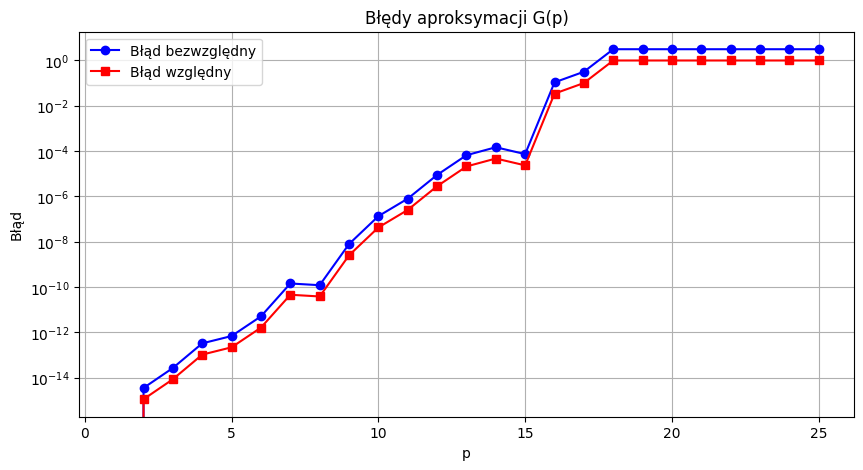


Odpowiedzi:
1. Analitycznie G(p) = pi dla każdego p (nie zależy od p).
2. Błąd rośnie wraz z p - tracimy cyfry znaczące.
3. Mamy do czynienia z błędem zaokrąglenia (round-off error)
   oraz utratą cyfr znaczących (catastrophic cancellation).


In [21]:
def G(n_max):
    pi_star = np.round(np.pi, 15)
    wyniki = np.zeros(n_max)
    for p in range(1, n_max + 1):
        wyniki[p - 1] = (1.0 / p) * (10.0**p * (1 + p * pi_star * 10.0**(-p)) - 10.0**p)
    return wyniki

n_max = 25
p_values = np.arange(1, n_max + 1)
G_values = G(n_max)
G_exact = np.pi

err_abs = np.abs(G_values - G_exact)
err_rel = err_abs / abs(G_exact)

print(f'{"p":>3} | {"G(p)":>20} | {"Błąd bezwzgl.":>15} | {"Błąd względny":>15}')
print('-' * 60)
for i in range(n_max):
    print(f'{p_values[i]:>3} | {G_values[i]:>20.15f} | {err_abs[i]:>15.2e} | {err_rel[i]:>15.2e}')

plt.figure(figsize=(10, 5))
plt.semilogy(p_values, err_abs, 'bo-', label='Błąd bezwzględny')
plt.semilogy(p_values, err_rel, 'rs-', label='Błąd względny')
plt.xlabel('p')
plt.ylabel('Błąd')
plt.title('Błędy aproksymacji G(p)')
plt.legend()
plt.grid()
plt.show()

print()
print('Odpowiedzi:')
print('1. Analitycznie G(p) = pi dla każdego p (nie zależy od p).')
print('2. Błąd rośnie wraz z p - tracimy cyfry znaczące.')
print('3. Mamy do czynienia z błędem zaokrąglenia (round-off error)')
print('   oraz utratą cyfr znaczących (catastrophic cancellation).')